# Evaluación del modelo predictivo Q-SOC / SOAR-IA

Este notebook documenta la evaluación técnica del modelo predictivo del proyecto Q-SOC / SOAR-IA. La evaluación se basa en un árbol de decisión entrenado con un dataset simulado de 2.000 eventos de ciberseguridad, clasificados como `normal`, `fallido` o `sospechoso`.

El objetivo es dejar evidencia reproducible de las métricas que se muestran en el dashboard y que pueden ser usadas como soporte técnico para el póster científico.

## 1. Cargar librerías

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
CLASES = ["normal", "fallido", "sospechoso"]

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

## 2. Definir rutas

In [2]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

RUTA_EVENTOS_ML = DATA_DIR / "eventos_ml_simulados.csv"
RUTA_METRICAS_ML = DATA_DIR / "metricas_arbol_decision.json"

print("Dataset ML:", RUTA_EVENTOS_ML)
print("Métricas ML:", RUTA_METRICAS_ML)
print("Directorio de figuras:", OUTPUTS_DIR)

Dataset ML: C:\Users\carva\OneDrive\Documentos\SOAR-IA\data\eventos_ml_simulados.csv
Métricas ML: C:\Users\carva\OneDrive\Documentos\SOAR-IA\data\metricas_arbol_decision.json
Directorio de figuras: C:\Users\carva\OneDrive\Documentos\SOAR-IA\outputs


## 3. Cargar dataset

Se carga el dataset simulado usado para entrenar y evaluar el árbol de decisión. Cada fila representa un evento de ciberseguridad con variables operativas, agregados simples por ventana y una etiqueta objetivo (`clase_evento_ml`).

In [3]:
df = pd.read_csv(RUTA_EVENTOS_ML)

print(f"Cantidad de registros: {len(df):,}")
print(f"Cantidad de columnas: {len(df.columns)}")

display(pd.DataFrame({"columnas": df.columns}))
display(df.head())

distribucion_clases = (
    df["clase_evento_ml"]
    .value_counts()
    .reindex(CLASES)
    .fillna(0)
    .astype(int)
)
display(distribucion_clases.rename_axis("clase").reset_index(name="cantidad"))

Cantidad de registros: 2,000
Cantidad de columnas: 21


,columnas
0,id_evento
1,timestamp
2,tipo_evento
3,servicio
4,usuario
5,hostname
6,ip_origen
7,ip_destino
8,hora_evento
9,es_horario_laboral


,id_evento,timestamp,tipo_evento,servicio,usuario,hostname,ip_origen,ip_destino,hora_evento,es_horario_laboral,...,usuario_privilegiado,host_critico,conteo_eventos_ip_ventana,conteo_usuarios_distintos_ip,conteo_hosts_distintos_ip,conteo_fallidos_ventana,servicio_sensible,severidad_inicial,resultado,clase_evento_ml
0,EVT-ML-0001,2026-06-10T02:57:00Z,ssh_authentication,ssh,backup,srv-web-01,10.10.50.23,10.10.40.12,2,0,...,1,1,3,1,1,4,1,Baja,fallido,fallido
1,EVT-ML-0002,2026-06-10T17:48:00Z,ssh_authentication,ssh,soporte,srv-app-01,172.16.10.20,10.10.40.12,17,1,...,0,1,3,2,1,0,1,Baja,permitido,normal
2,EVT-ML-0003,2026-06-10T16:07:00Z,file_access,os,analyst,ws-analyst-07,192.0.2.14,10.10.20.15,16,1,...,0,0,5,2,2,0,1,Baja,permitido,normal
3,EVT-ML-0004,2026-06-10T11:40:00Z,file_access,os,deploy,ws-analyst-07,10.10.20.20,10.10.30.21,11,1,...,1,0,3,1,2,0,1,Baja,permitido,normal
4,EVT-ML-0005,2026-06-10T21:35:00Z,network_connection,https,soporte,srv-db-01,10.10.30.21,10.10.20.15,21,0,...,0,1,6,1,2,7,0,Baja,fallido,fallido


,clase,cantidad
0,normal,1114
1,fallido,492
2,sospechoso,394


## 4. Gráfico de distribución de clases

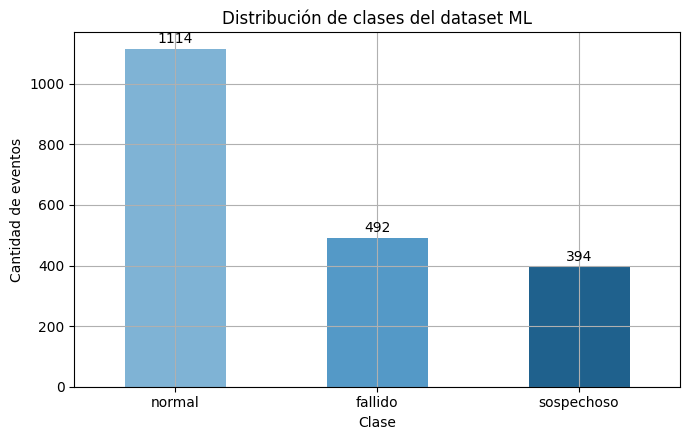

In [4]:
OUTPUTS_DIR.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4.5))
distribucion_clases.plot(kind="bar", ax=ax, color=["#7fb3d5", "#5499c7", "#1f618d"])
ax.set_title("Distribución de clases del dataset ML")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de eventos")
ax.tick_params(axis="x", rotation=0)

for indice, valor in enumerate(distribucion_clases.values):
    ax.text(indice, valor + 10, str(valor), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "distribucion_clases_ml.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Preparación de datos

- `X` contiene las variables predictoras usadas por el modelo.
- `y` contiene la etiqueta objetivo `clase_evento_ml`.
- Se excluyen columnas que pueden generar fuga de información o que no son útiles para entrenamiento directo.

Columnas excluidas:

- `id_evento`
- `timestamp`
- `ip_origen`
- `ip_destino`
- `resultado`
- `clase_evento_ml`

La columna `resultado` se conserva en el dataset para trazabilidad, pero no se usa como feature para evitar que el árbol aprenda una regla demasiado directa.

In [5]:
COLUMNAS_EXCLUIDAS = [
    "id_evento",
    "timestamp",
    "ip_origen",
    "ip_destino",
    "resultado",
    "clase_evento_ml",
]

COLUMNAS_CATEGORICAS = [
    "tipo_evento",
    "servicio",
    "usuario",
    "hostname",
    "severidad_inicial",
]

COLUMNAS_NUMERICAS = [
    "hora_evento",
    "es_horario_laboral",
    "ip_origen_es_privada",
    "usuario_privilegiado",
    "host_critico",
    "conteo_eventos_ip_ventana",
    "conteo_usuarios_distintos_ip",
    "conteo_hosts_distintos_ip",
    "conteo_fallidos_ventana",
    "servicio_sensible",
]

FEATURES_USADAS = COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS

X = df[FEATURES_USADAS].copy()
y = df["clase_evento_ml"].copy()

display(pd.DataFrame({"features_usadas": FEATURES_USADAS}))
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

,features_usadas
0,tipo_evento
1,servicio
2,usuario
3,hostname
4,severidad_inicial
5,hora_evento
6,es_horario_laboral
7,ip_origen_es_privada
8,usuario_privilegiado
9,host_critico


Dimensiones de X: (2000, 15)
Dimensiones de y: (2000,)


## 6. Separación train/test

Se usa una separación reproducible con `random_state=42`, `test_size=0.25` y `stratify=y` para conservar la proporción de clases en entrenamiento y prueba.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"Total de entrenamiento: {len(X_train):,}")
print(f"Total de prueba: {len(X_test):,}")

display(y_train.value_counts().reindex(CLASES).rename("train"))
display(y_test.value_counts().reindex(CLASES).rename("test"))

Total de entrenamiento: 1,500
Total de prueba: 500


clase_evento_ml
normal        836
fallido       369
sospechoso    295
Name: train, dtype: int64

clase_evento_ml
normal        278
fallido       123
sospechoso     99
Name: test, dtype: int64

## 7. Entrenamiento del modelo

El modelo usa un `Pipeline` con `ColumnTransformer` y `OneHotEncoder` para codificar variables categóricas. El árbol se mantiene pequeño para reducir riesgo de sobreentrenamiento.

In [7]:
def crear_one_hot_encoder():
    """Compatibilidad entre versiones nuevas y anteriores de scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


preprocesador = ColumnTransformer(
    transformers=[
        ("categoricas", crear_one_hot_encoder(), COLUMNAS_CATEGORICAS),
        ("numericas", "passthrough", COLUMNAS_NUMERICAS),
    ]
)

modelo = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=25,
    min_samples_split=50,
    random_state=RANDOM_STATE,
    class_weight="balanced",
)

pipeline = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        ("modelo", modelo),
    ]
)

pipeline.fit(X_train, y_train)
print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 8. Evaluación del modelo

Se calculan métricas globales y por clase: accuracy, precision, recall, F1-score, reporte de clasificación y matriz de confusión.

In [8]:
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_test, y_pred, average="weighted", zero_division=0
)

metricas_principales = pd.DataFrame(
    [
        {"métrica": "Accuracy", "valor": accuracy, "porcentaje": accuracy * 100},
        {"métrica": "Error Rate", "valor": 1 - accuracy, "porcentaje": (1 - accuracy) * 100},
        {"métrica": "Precision macro", "valor": precision_macro, "porcentaje": precision_macro * 100},
        {"métrica": "Recall macro", "valor": recall_macro, "porcentaje": recall_macro * 100},
        {"métrica": "F1-score macro", "valor": f1_macro, "porcentaje": f1_macro * 100},
        {"métrica": "Precision weighted", "valor": precision_weighted, "porcentaje": precision_weighted * 100},
        {"métrica": "Recall weighted", "valor": recall_weighted, "porcentaje": recall_weighted * 100},
        {"métrica": "F1-score weighted", "valor": f1_weighted, "porcentaje": f1_weighted * 100},
    ]
)

display(metricas_principales)

print("Classification report:")
print(classification_report(y_test, y_pred, labels=CLASES, zero_division=0))

matriz_confusion = confusion_matrix(y_test, y_pred, labels=CLASES)
df_matriz_confusion = pd.DataFrame(
    matriz_confusion,
    index=[f"Real: {clase}" for clase in CLASES],
    columns=[f"Pred: {clase}" for clase in CLASES],
)
display(df_matriz_confusion)

,métrica,valor,porcentaje
0,Accuracy,0.934000,93.400000
1,Error Rate,0.066000,6.600000
2,Precision macro,0.929487,92.948718
3,Recall macro,0.945256,94.525592
4,F1-score macro,0.932005,93.200487
5,Precision weighted,0.947962,94.796154
6,Recall weighted,0.934000,93.400000
7,F1-score weighted,0.936371,93.637121


Classification report:
              precision    recall  f1-score   support

      normal       1.00      0.91      0.95       278
     fallido       0.79      1.00      0.88       123
  sospechoso       1.00      0.93      0.96        99

    accuracy                           0.93       500
   macro avg       0.93      0.95      0.93       500
weighted avg       0.95      0.93      0.94       500



,Pred: normal,Pred: fallido,Pred: sospechoso
Real: normal,252,26,0
Real: fallido,0,123,0
Real: sospechoso,0,7,92


Los resultados esperados deben quedar alineados con las métricas usadas por el dashboard:

- Accuracy aproximado: 93.4%
- Error Rate aproximado: 6.6%
- Precision macro aproximado: 92.9%
- Recall macro aproximado: 94.5%
- F1-score macro aproximado: 93.2%

In [9]:
if RUTA_METRICAS_ML.exists():
    with RUTA_METRICAS_ML.open("r", encoding="utf-8") as archivo:
        metricas_dashboard = json.load(archivo)
    print("Métricas guardadas para el dashboard:")
    display(pd.DataFrame([metricas_dashboard.get("metricas", {})]).T.rename(columns={0: "valor"}))
else:
    print("No se encontró data/metricas_arbol_decision.json para comparar.")

Métricas guardadas para el dashboard:


,valor
accuracy,0.934000
precision_macro,0.929487
recall_macro,0.945256
f1_macro,0.932005
precision_weighted,0.947962
recall_weighted,0.934000
f1_weighted,0.936371


## 9. Gráfico de barras de métricas

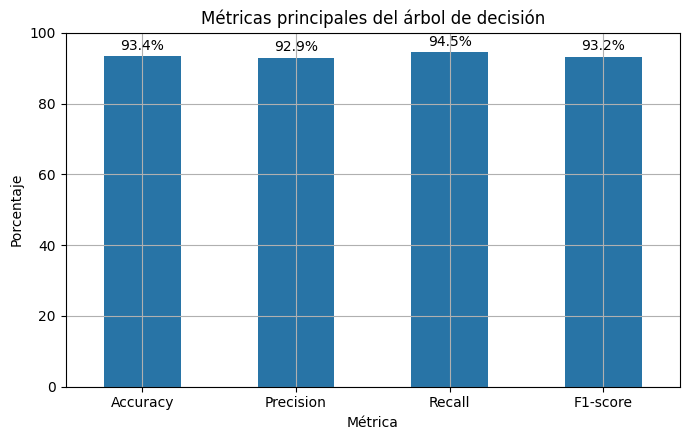

In [10]:
metricas_para_grafico = pd.Series(
    {
        "Accuracy": accuracy * 100,
        "Precision": precision_macro * 100,
        "Recall": recall_macro * 100,
        "F1-score": f1_macro * 100,
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
metricas_para_grafico.plot(kind="bar", ax=ax, color="#2874a6")
ax.set_title("Métricas principales del árbol de decisión")
ax.set_xlabel("Métrica")
ax.set_ylabel("Porcentaje")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)

for indice, valor in enumerate(metricas_para_grafico.values):
    ax.text(indice, valor + 1, f"{valor:.1f}%", ha="center", va="bottom")

fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "metricas_arbol_decision.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Matriz de confusión

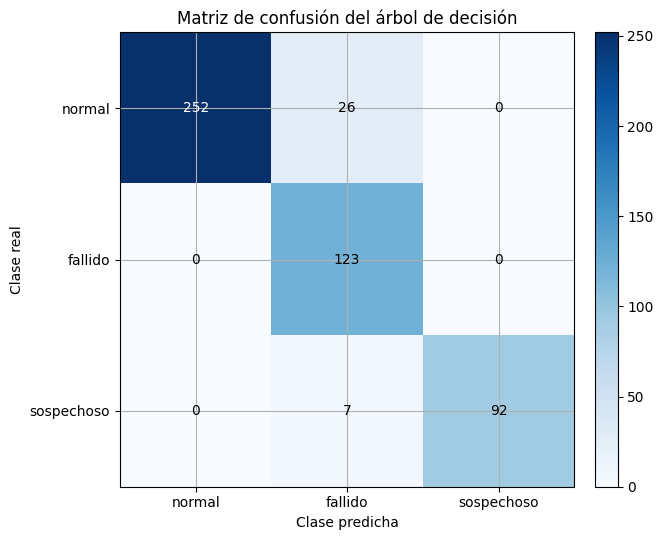

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
imagen = ax.imshow(matriz_confusion, cmap="Blues")

ax.set_title("Matriz de confusión del árbol de decisión")
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.set_xticks(np.arange(len(CLASES)))
ax.set_yticks(np.arange(len(CLASES)))
ax.set_xticklabels(CLASES)
ax.set_yticklabels(CLASES)

umbral = matriz_confusion.max() / 2
for fila in range(matriz_confusion.shape[0]):
    for columna in range(matriz_confusion.shape[1]):
        valor = matriz_confusion[fila, columna]
        color_texto = "white" if valor > umbral else "black"
        ax.text(columna, fila, str(valor), ha="center", va="center", color=color_texto)

fig.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "matriz_confusion_arbol_decision.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Interpretación de resultados

El modelo obtuvo buen desempeño general para un MVP académico, con un accuracy cercano al 93.4% y un F1-score macro cercano al 93.2%.

La matriz de confusión esperada refleja que el árbol clasificó correctamente todos los eventos fallidos del conjunto de prueba. La mayoría de eventos normales y sospechosos también fueron clasificados correctamente. El principal error observado fue clasificar algunos eventos normales o sospechosos como fallidos.

Desde el punto de vista SOC, este comportamiento es aceptable para una etapa de apoyo predictivo: el modelo puede funcionar como sensor inicial que prioriza eventos potencialmente relevantes antes de que el flujo aplique reglas, MITRE ATT&CK, playbooks y análisis asistido por Qwen.

## 12. Conclusión técnica

El árbol de decisión entrega una señal predictiva útil para el agente Q-SOC / SOAR-IA. Esta señal no reemplaza la lógica de detección, severidad, MITRE ATT&CK, playbooks ni el análisis con Qwen; funciona como una capa adicional de clasificación temprana.

En el flujo completo del MVP, la predicción ML puede ayudar a decidir cuándo conviene activar análisis avanzado y cuándo basta con mantener el análisis base mediante reglas, evidencia y playbooks.

## 13. Figuras generadas al ejecutar el notebook

Al ejecutar las celdas de gráficos, se guardan las siguientes figuras en la carpeta `outputs/`:

- `outputs/distribucion_clases_ml.png`
- `outputs/metricas_arbol_decision.png`
- `outputs/matriz_confusion_arbol_decision.png`

Estos archivos son artefactos de apoyo para presentación, dashboard o póster científico. No sobrescriben archivos críticos del proyecto.